# Practica 04: Analisis de datos exploratorio de python y Jypiter notebook en dataset de productos de amazon store

**Programa de estudios** Ingenieria de entornos virtuales y negocios digitales \
**Asignatura:** Analitica de datos digitales y negocios \
**Docente:** M.T.I. Marco A. Ramirez Hernández \
**Periodo:** Mayo-Agosto 2026 

### Unidad 2: Preparación de datos 

**Nombre del estudiante:** Samantha Salazar Fernández \
**Matricula:** 230004 \
**Grado y grpo:** 9A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)</h1>
<p style="color: #FFD700; text-align: center; font-size: 1.1em; margin-top: 10px;">Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos</p>
</div>

## Tabla de contenido 
|# | Sección | Descripcion |
|---|---|---|
|1|[Instalaciones & Carga de datos](#s1)|Librerias, cargas del cvs, primeros comandos de estructuras|
|2|[Diccionario de datos](#s2)|Explicacion de contenido de columnas y calcular el % porcentaje de datos|
|3|[Limpieza de datos](#s3)|Aplicaci+on de metdos basicos de limpieza (eliminacion de duplicados, agrupació y datos nulos)|

## 1. Instalaciones & Carga de Datos 🔌 <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Dataset:</b> Amazon India Listas de Prductos - 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y diponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [68]:
# =================================
# Section 1 -Setup & Data loading 
# =================================
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as pit
import matplotlib.ticker as sticker
import seaborn as sns 
import warnings 


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro


from scipy.stats import kruskal, mannwhitneyu, spearmanr
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'Pandas : {pd.__version__}')
print(f'Numpy : {np.__version__}')
print(f'Todas las librerias cargaron con exito!')

Pandas : 2.3.3
Numpy : 2.3.5
Todas las librerias cargaron con exito!


In [3]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f'Shape : {df_raw.shape}')
print(f'Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

Shape : (1444, 17)
Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de datos de dataframe <a id='s2'></a>

In [5]:
col_info = {
    'url': 'URL del producto en Amazon.in',
    'asin': 'Número estandarizado de identificación por Amazon (ID único)',
    'name': 'Nombre o título del producto',
    'overview': 'Breve reseña del producto (mayoría vacío [])',
    'price': 'Precio como string (ej. "1,600.00")',
    'currency': 'Código de divisa (todas en INR)',
    'availability': 'Texto del estado del stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URL de la imagen principal',
    'description': 'Descripción detallada y completa',
    'specification': 'Especificaciones técnicas',
    'primary_category': 'Categoría principal',
    'category_1': 'Categoría de nivel 1',
    'category_2': 'Categoría de nivel 2',
    'category_3': 'Categoría de nivel 3',
    'breadcrumbs': 'Ruta de navegación de categorías'
}

print('Diccionario de columnas')
print('-' * 90)

for col, desc in col_info.items():
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100

        print(
            f'{col:20s}| '
            f'{desc[:45]:45s}| '
            f'Missing: {missing_pct:.0f}%'
        )
    else:
        print(
            f'{col:20s}| '
            f'{desc[:45]:45s}| '
            f'NO EXISTE EN EL DATAFRAME'
        )

Diccionario de columnas
------------------------------------------------------------------------------------------
url                 | URL del producto en Amazon.in                | NO EXISTE EN EL DATAFRAME
asin                | Número estandarizado de identificación por Am| Missing: 0%
name                | Nombre o título del producto                 | Missing: 0%
overview            | Breve reseña del producto (mayoría vacío []) | Missing: 0%
price               | Precio como string (ej. "1,600.00")          | Missing: 24%
currency            | Código de divisa (todas en INR)              | Missing: 24%
availability        | Texto del estado del stock (Inventario)      | Missing: 33%
brand               | Nombre de la Marca/Autor                     | Missing: 1%
about_item          | Detalles/Especificaciones (mayoría faltante) | Missing: 92%
img_source          | URL de la imagen principal                   | Missing: 0%
description         | Descripción detallada y completa   

## 3.Limpieza de datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [7]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# Parse price
def clean_price(p):
    if pd.isna(p):
        return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# Standardise availability
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'
    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'
    if 'unavailable' in a:
        return 'Unavailable'
    if '1 to 3' in a:
        return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a:
        return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# Text length features
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# Duplicate check
dupes = df.duplicated(subset='asin').sum()

print(f'Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'Duplicate ASINs: {dupes}')
print(f'Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

Price parsed: 1,100 / 1,444 products
Duplicate ASINs: 5
Availability categories: {'In Stock': 611, 'Unknown': 478, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


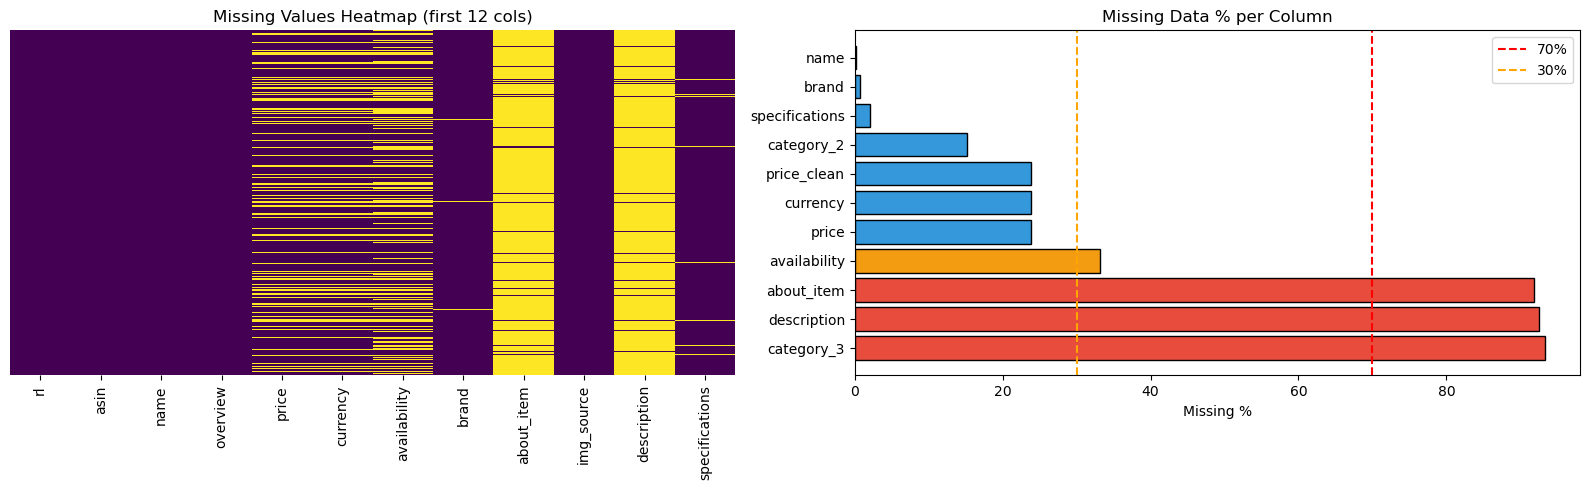

                Missing Count  Missing Pct
category_3               1348         93.4
description              1336         92.5
about_item               1325         91.8
availability              478         33.1
price                     344         23.8
currency                  344         23.8
price_clean               344         23.8
category_2                220         15.2
specifications             29          2.0
brand                      10          0.7
name                        1          0.1


In [8]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

# Crear figura
fig, axes = pit.subplots(1, 2, figsize=(16, 5))

# Heatmap de valores faltantes
sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title('Missing Values Heatmap (first 12 cols)')

# Filtrar columnas con valores faltantes
mv = missing[missing['Missing Pct'] > 0]

# Colores según porcentaje de faltantes
colors_mv = [
    '#e74c3c' if v > 70
    else '#F39c12' if v > 30
    else '#3498db'
    for v in mv['Missing Pct']
]

# Gráfico de barras
axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')

axes[1].legend()
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

pit.tight_layout()
pit.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feauturing Engineering)

<div style="background: #f0fff0; padding: 12px; border-left:4px solid #27ae68; border-radius: 5px; color: #0066cc;">
<b> Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que tambiénconsidera la ubicación, la antigüedad y
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [23]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        287
3_mid        320
4_premium    262
5_luxury     127
Unknown      344


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariado

El análisis univariado estudia una sola variable a la vez para comprender su comportamiento y características principales.

In [16]:
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')

def price_tier(p):
    if pd.isna(p):
        return 'Unknown'
    elif p < 300:
        return '1_budget'
    elif p < 800:
        return '2_low'
    elif p < 1500:
        return '3_mid'
    elif p < 3000:
        return '4_premium'
    else:
        return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

print("✔ price_tier creada correctamente")
print(df['price_tier'].value_counts().sort_index())

✔ price_tier creada correctamente
price_tier
1_budget     105
2_low        286
3_mid        320
4_premium    262
5_luxury     127
Unknown      344
Name: count, dtype: int64


In [17]:
print('price_tier' in df.columns)

True


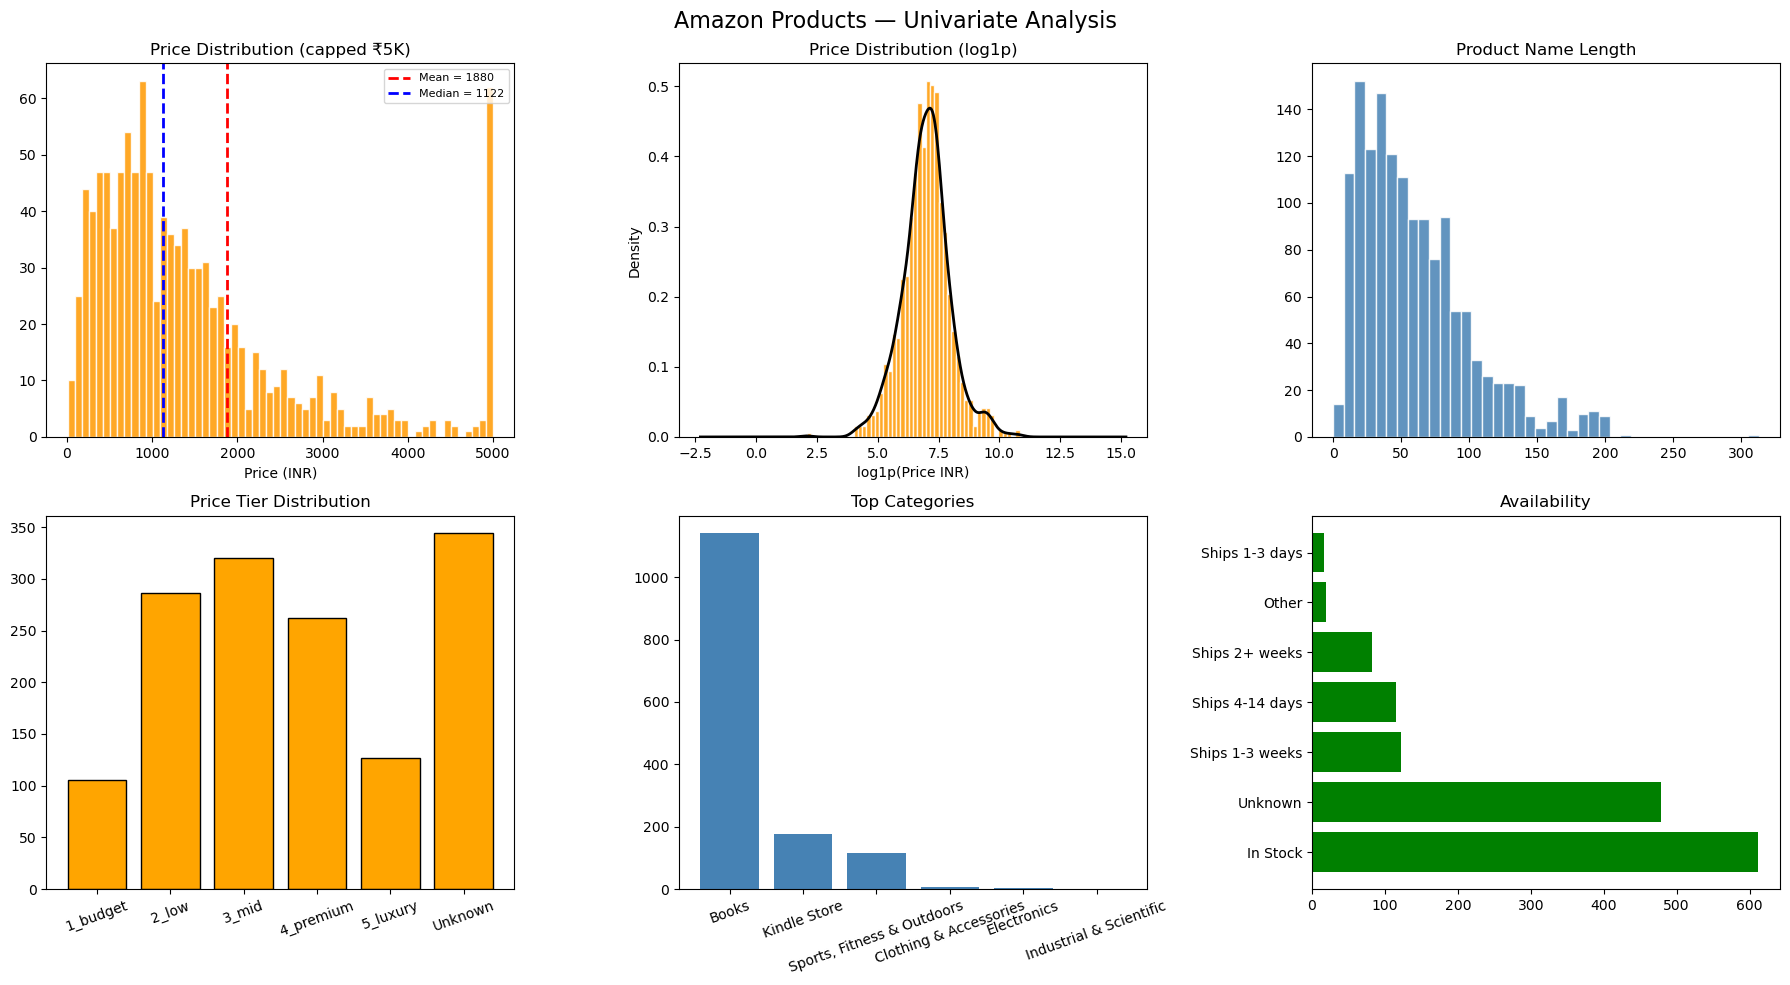

Shapiro-Wilk: stat=0.9872, p=0.000230
→ Log price NOT normal
count     1093.00
mean      1879.84
std       3332.37
min          7.00
25%        613.06
50%       1122.00
75%       1850.00
max      50555.00
Name: price_clean, dtype: float64


In [18]:
# ============================================================
# SECTION 4 — Univariate Analysis (CORREGIDO)
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import shapiro

# ── Asegurar que price_clean sea numérico ───────────────────
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')

# ── Subset seguro ────────────────────────────────────────────
df_priced = df[
    df['price_clean'].notna() &
    (df['price_clean'] > 0)
].copy()

# ── Asegurar log_price exista ───────────────────────────────
df_priced['log_price'] = np.log1p(df_priced['price_clean'])

# ── Crear figura ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ============================================================
# 1. Price distribution (raw)
# ============================================================
axes[0, 0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

axes[0, 0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f"Mean = {df_priced['price_clean'].mean():.0f}"
)

axes[0, 0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f"Median = {df_priced['price_clean'].median():.0f}"
)

axes[0, 0].set_title('Price Distribution (capped ₹5K)')
axes[0, 0].set_xlabel('Price (INR)')
axes[0, 0].legend(fontsize=8)

# ============================================================
# 2. Log price distribution
# ============================================================
axes[0, 1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(
    ax=axes[0, 1],
    color='black',
    lw=2
)

axes[0, 1].set_title('Price Distribution (log1p)')
axes[0, 1].set_xlabel('log1p(Price INR)')

# ============================================================
# 3. Name length (SAFE CHECK)
# ============================================================
if 'name_length' in df.columns:
    axes[0, 2].hist(
        df['name_length'].dropna(),
        bins=40,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[0, 2].set_title('Product Name Length')
else:
    axes[0, 2].text(0.5, 0.5, 'name_length NOT FOUND', ha='center')

# ============================================================
# 4. Price tier (FIX PRINCIPAL)
# ============================================================
if 'price_tier' in df.columns:
    tier_counts = df['price_tier'].value_counts().sort_index()

    axes[1, 0].bar(
        tier_counts.index.astype(str),
        tier_counts.values,
        color='orange',
        edgecolor='black'
    )

    axes[1, 0].set_title('Price Tier Distribution')
    axes[1, 0].tick_params(axis='x', rotation=20)

else:
    axes[1, 0].text(0.5, 0.5, 'price_tier NOT FOUND', ha='center')

# ============================================================
# 5. Category (SAFE)
# ============================================================
if 'primary_category' in df.columns:
    cat_counts = df['primary_category'].value_counts().head(10)

    axes[1, 1].bar(
        cat_counts.index.astype(str),
        cat_counts.values,
        color='steelblue'
    )

    axes[1, 1].set_title('Top Categories')
    axes[1, 1].tick_params(axis='x', rotation=20)
else:
    axes[1, 1].text(0.5, 0.5, 'primary_category NOT FOUND', ha='center')

# ============================================================
# 6. Availability (SAFE)
# ============================================================
if 'avail_clean' in df.columns:
    avail_counts = df['avail_clean'].value_counts()

    axes[1, 2].barh(
        avail_counts.index.astype(str),
        avail_counts.values,
        color='green'
    )

    axes[1, 2].set_title('Availability')
else:
    axes[1, 2].text(0.5, 0.5, 'avail_clean NOT FOUND', ha='center')

# ============================================================
# Layout
# ============================================================
plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================
# Normality test (SAFE)
# ============================================================
sample = df_priced['log_price'].dropna()

if len(sample) > 3:
    sample = sample.sample(min(500, len(sample)), random_state=42)

    stat, p = shapiro(sample)

    print(f"Shapiro-Wilk: stat={stat:.4f}, p={p:.6f}")

    if p > 0.05:
        print("→ Log price ~ normal")
    else:
        print("→ Log price NOT normal")

# ============================================================
# Stats
# ============================================================
print(df_priced['price_clean'].describe().round(2))

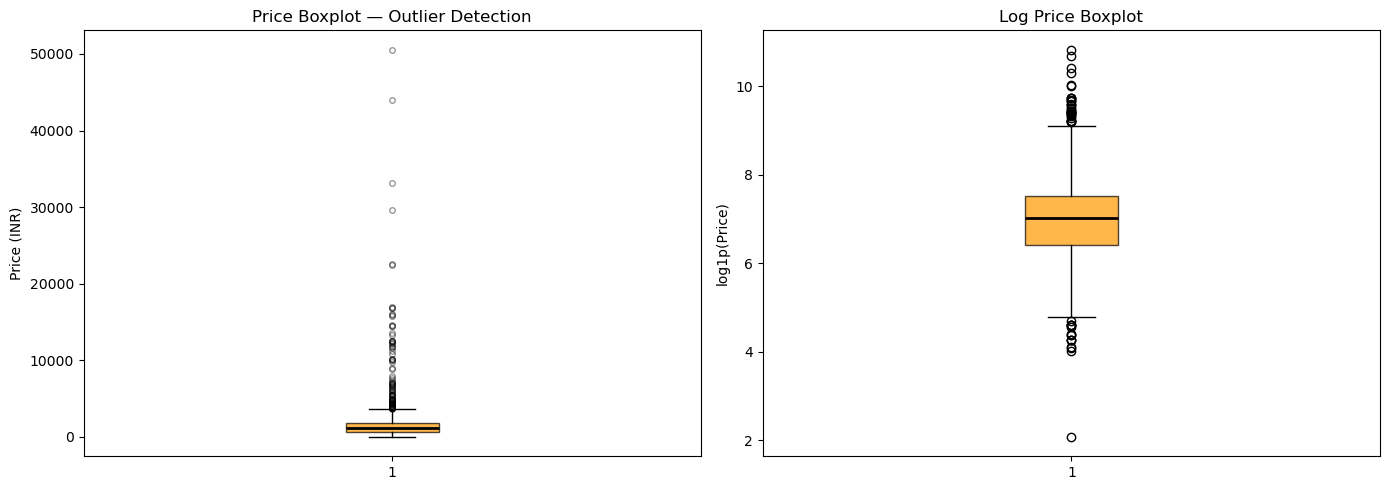

IQR method outliers: 94 (8.6%)
Price range (non-outlier): ₹-1242 – ₹3705

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [19]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis por Categoría

Comparar los precios entre categorías y subcategorías para identificar cuáles contienen los productos más caros, cuáles predominan en el catálogo y 
dónde se concentra el mayor valor económico.

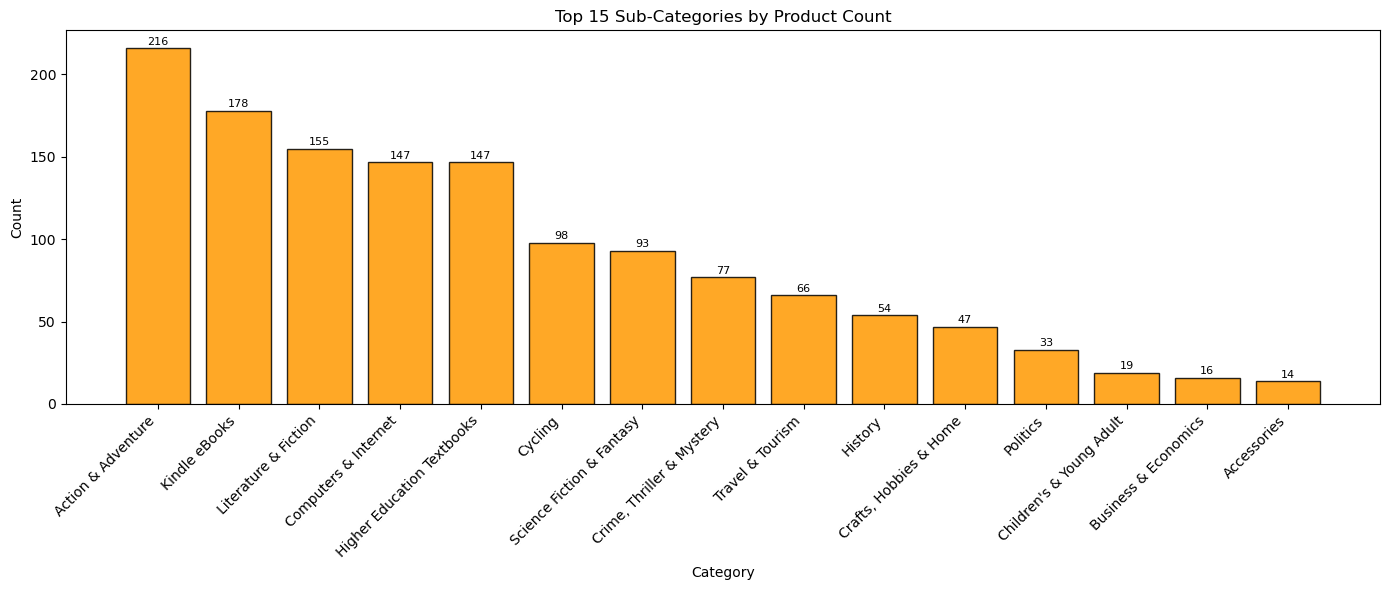

In [20]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

C:\Users\PC-08\AppData\Local\Temp\ipykernel_4936\1881029386.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,


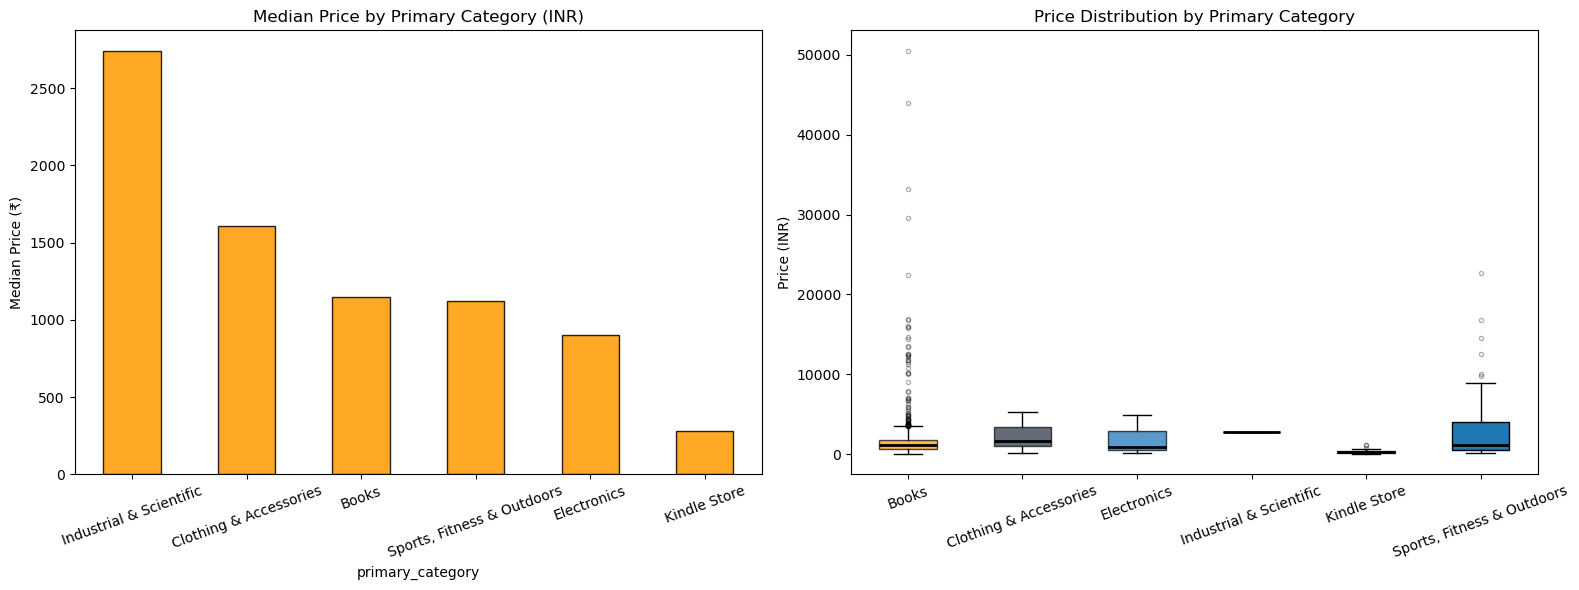

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1824.5  1145.0    960
Clothing & Accessories      2249.2  1606.5      6
Electronics                 1995.7   899.0      3
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [21]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()
print('Price stats by primary category:')
print(cat_price.to_string())

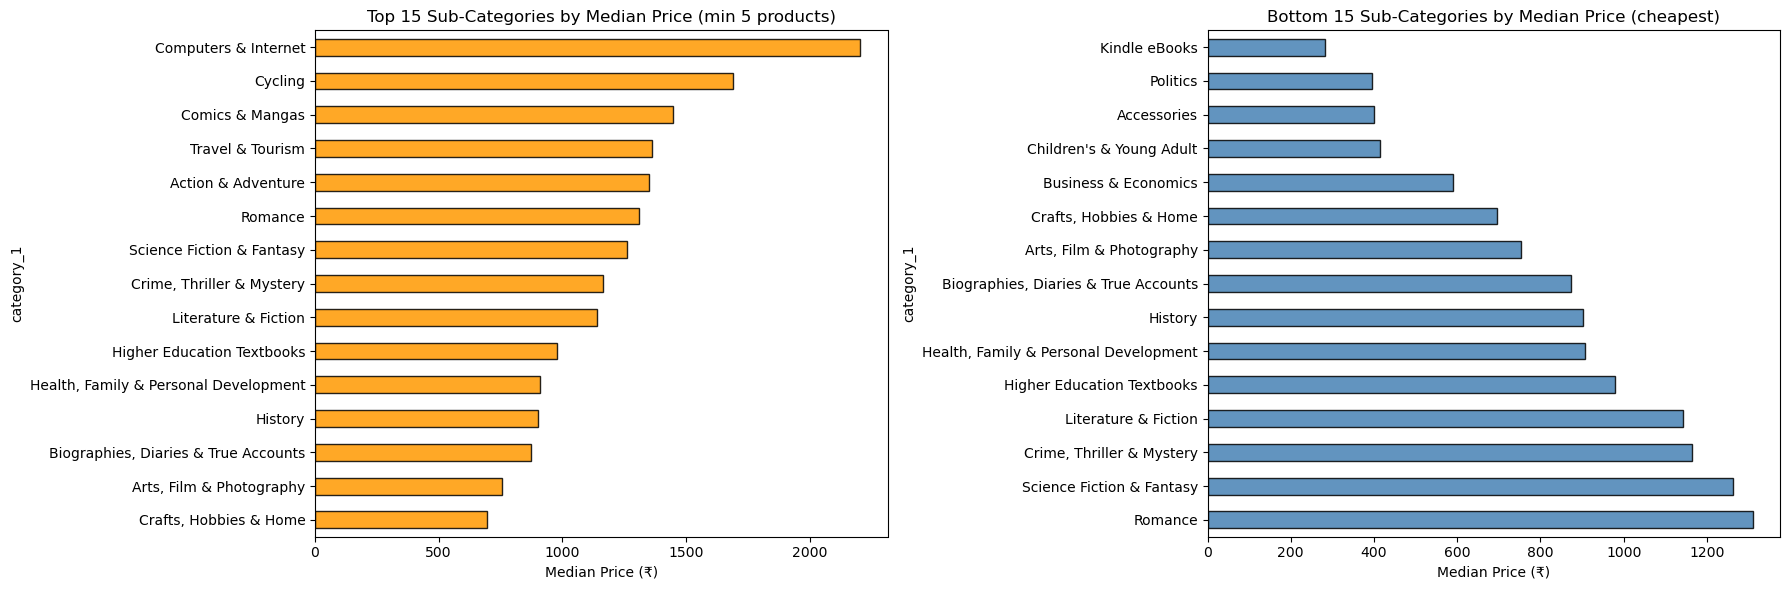

In [22]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.Análisis de Disponibilidad

In [ ]:
Examinar cómo el estado de disponibilidad (In Stock, Out of Stock, etc.) se relaciona con el precio de los productos y 
determinar si los artículos premium tienen una mayor probabilidad de estar agotados.

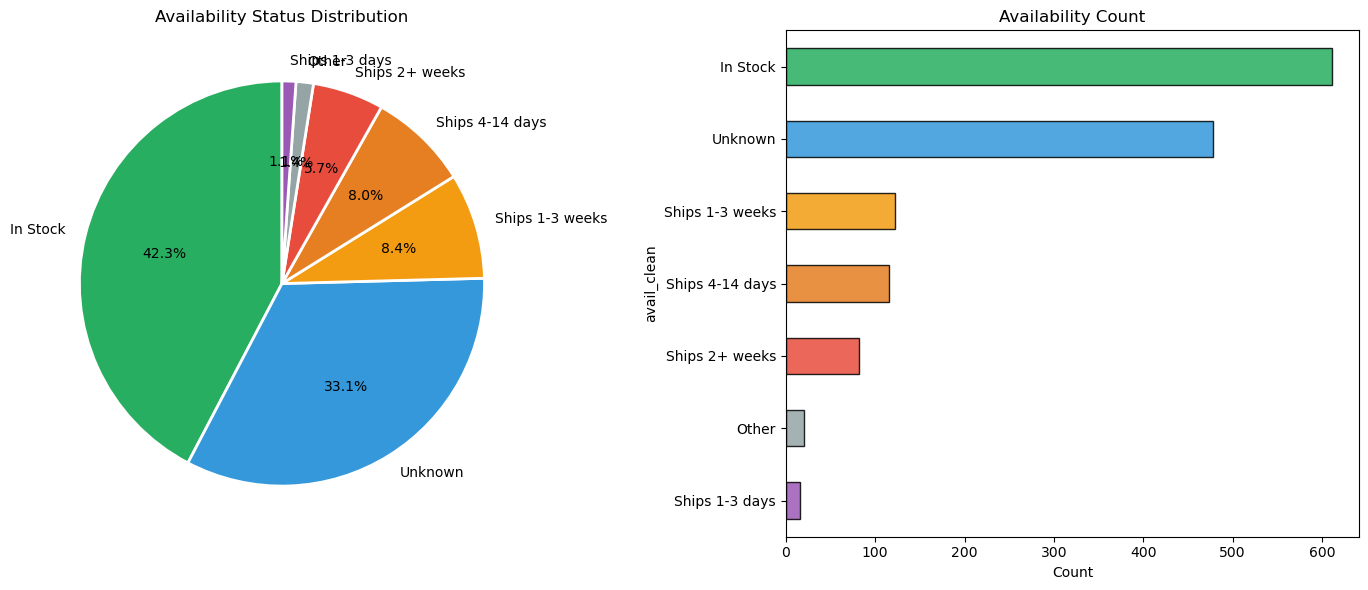

In [23]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

C:\Users\PC-08\AppData\Local\Temp\ipykernel_4936\1063884491.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,


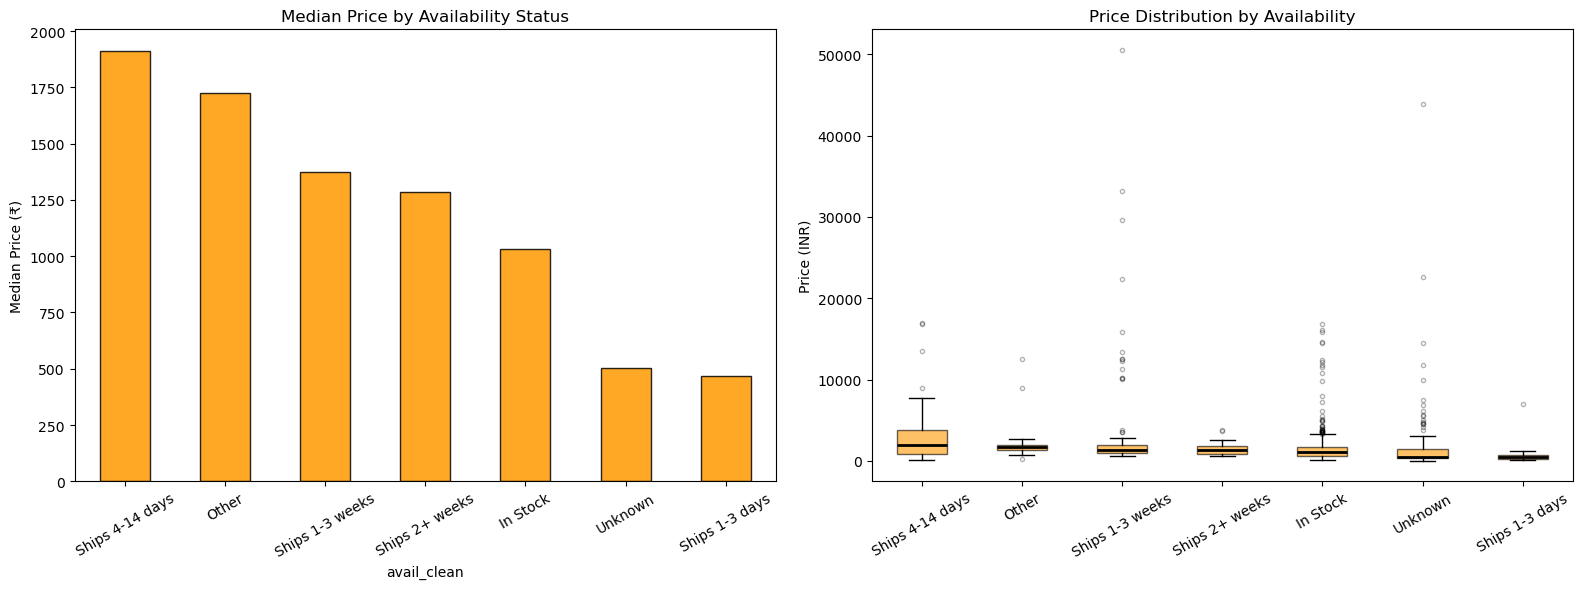

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1376.0  3210.8    122
Ships 2+ weeks   1284.5  1403.9     82
In Stock         1030.0  1493.1    603
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [24]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8.Análisis de Correlación y Bivariado

Analizar la relación entre dos variables para identificar cuáles características están más asociadas con el precio del 
producto y determinar qué factores pueden ayudar a predecirlo.

In [27]:
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
df['log_price'] = np.log1p(df['price_clean'])

print("✔ log_price creado")

✔ log_price creado


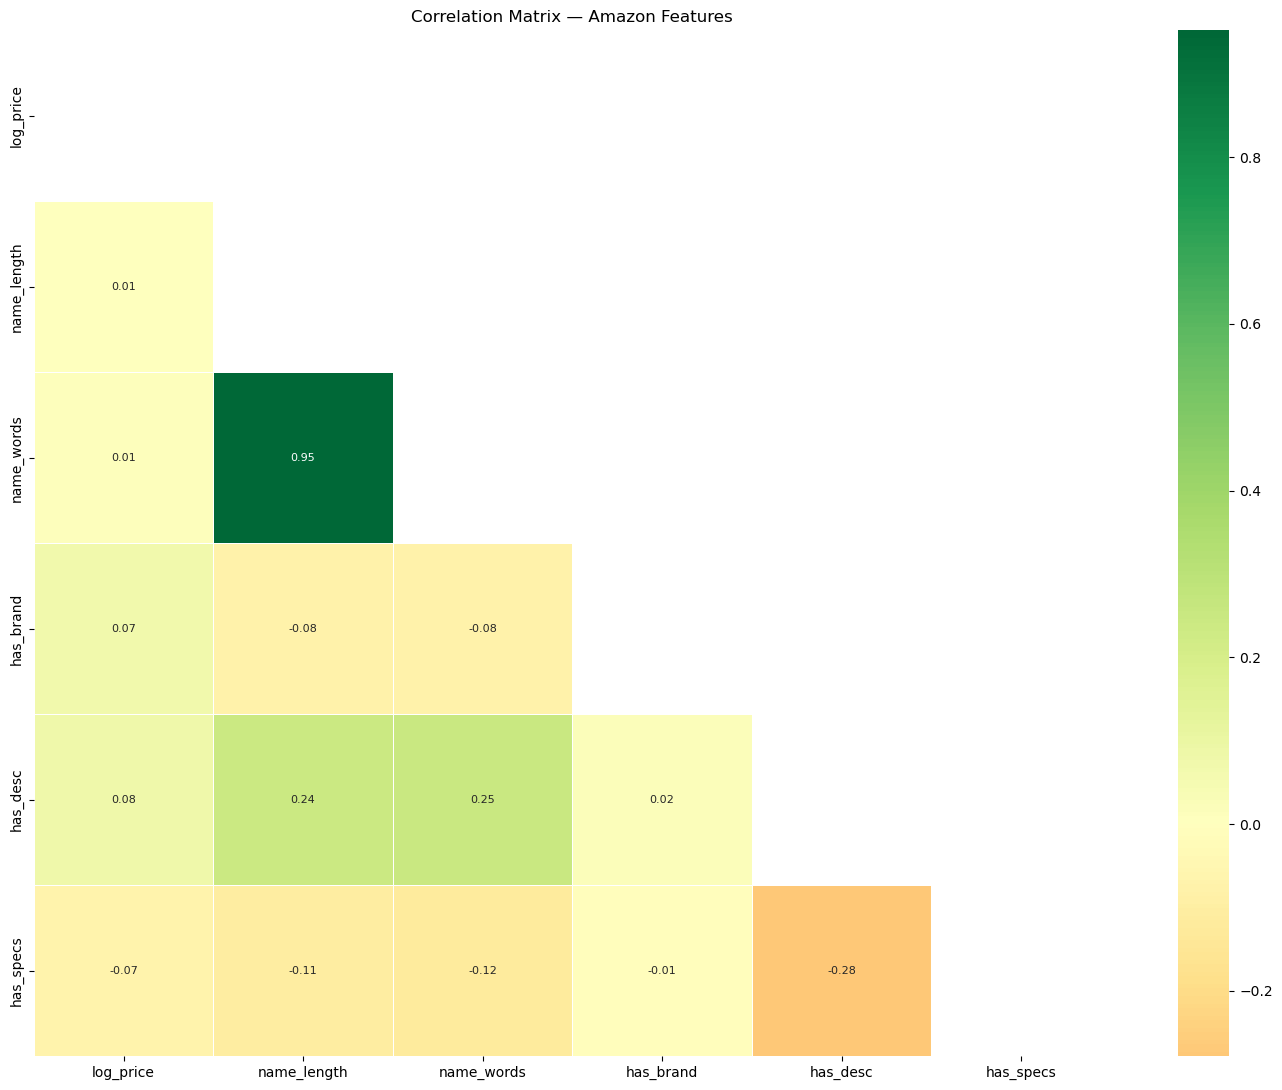


Top correlations with log_price:
has_desc       0.081911
has_brand      0.069553
name_words     0.014808
name_length    0.007530
has_specs     -0.069738


In [28]:
corr_cols = [
    'log_price','name_length','name_words','has_brand','has_desc',
    'has_specs','is_book','is_kindle','is_sports','is_fiction',
    'is_nonfiction','is_tech','is_cycling','is_instock',
    'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc'
]

# Solo columnas que EXISTEN
valid_cols = [c for c in corr_cols if c in df.columns]

corr = df[valid_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

plt.title('Correlation Matrix — Amazon Features')
plt.tight_layout()
plt.show()

# Solo si log_price existe
if 'log_price' in corr.columns:
    print('\nTop correlations with log_price:')
    print(
        corr['log_price']
        .drop('log_price')
        .sort_values(ascending=False)
        .to_string()
    )
else:
    print("⚠ log_price no está en el dataset")

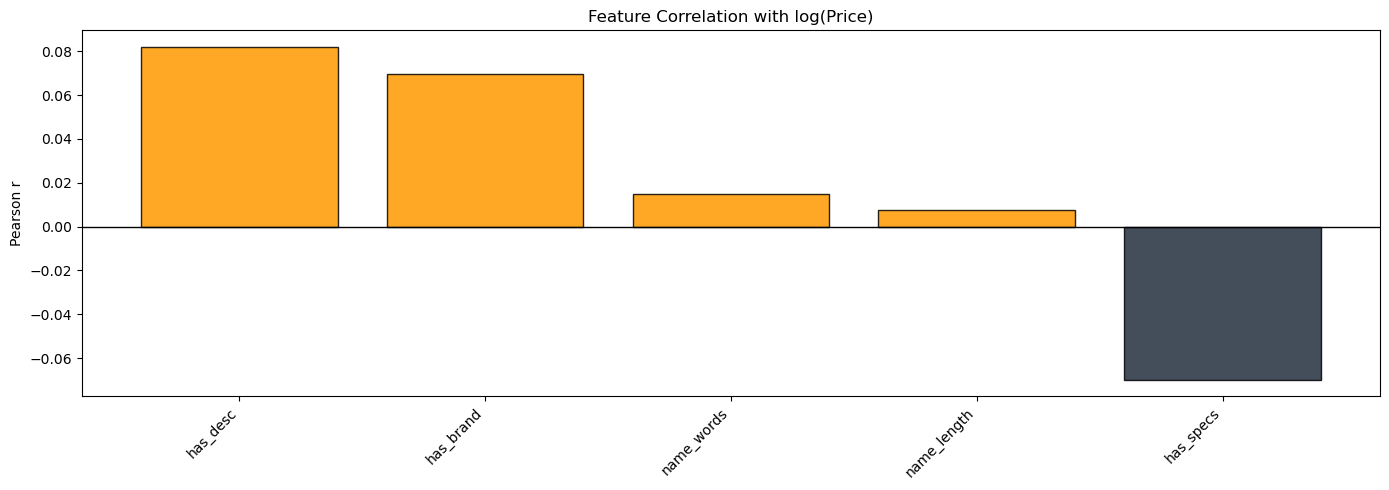

In [29]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [36]:
from sklearn.preprocessing import LabelEncoder

le_cat = LabelEncoder()

df['primary_cat_enc'] = le_cat.fit_transform(
    df['primary_category'].fillna('Unknown')
)

In [37]:
df_priced = df[
    df['price_clean'].notna() &
    (df['price_clean'] > 0)
].copy()

In [38]:
df_priced['log_price'] = np.log1p(df_priced['price_clean'])

In [39]:
df_priced['primary_cat_enc'] = df['primary_cat_enc']

C:\Users\PC-08\AppData\Local\Temp\ipykernel_4936\2849255280.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


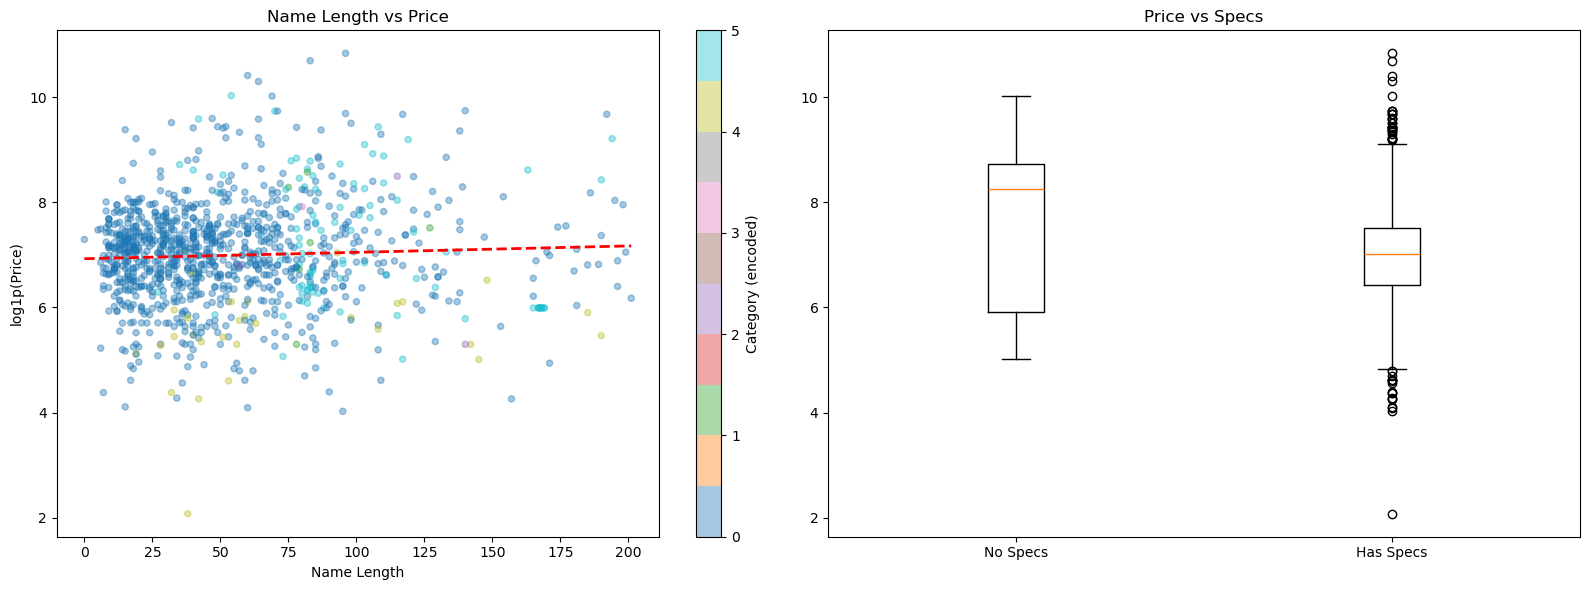

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_priced['log_price'] = np.log1p(df_priced['price_clean'])

# Scatter
sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

plt.colorbar(sc, ax=axes[0], label='Category (encoded)')

m, b = np.polyfit(
    df_priced['name_length'],
    df_priced['log_price'],
    1
)

x = np.linspace(0, df_priced['name_length'].max(), 100)

axes[0].plot(x, m*x + b, 'r--', lw=2)

axes[0].set_xlabel('Name Length')
axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price')

# Boxplot
axes[1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs'] == 0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs'] == 1]['price_clean'])
    ],
    labels=['No Specs', 'Has Specs']
)

axes[1].set_title('Price vs Specs')

plt.tight_layout()
plt.show()

## 9.Pruebas de Hipótesis Estadísticas

Determinar si existen diferencias estadísticamente significativas en los precios entre grupos de productos utilizando pruebas 
no paramétricas, ya que la variable precio presenta una distribución sesgada y no normal.

| H# | Hipótesis | Prueba |
|----|-----------|--------|
| H1 | El precio difiere significativamente entre categorías principales | Kruskal-Wallis |
| H2 | El precio de libros es significativamente menor que el de productos deportivos | Mann-Whitney U |
| H3 | Los productos en stock tienen precios diferentes a los no disponibles | Mann-Whitney U |
| H4 | La longitud del nombre está positivamente correlacionada con el precio | Correlación de Spearman |
| H5 | Los productos con especificaciones tienen precios más altos | Mann-Whitney U |

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr, kruskal

In [63]:
df_priced['log_price'] = np.log1p(df_priced['price_clean'])

In [64]:
# =========================
# H1 (Kruskal - categorías)
# =========================
# p1 debe venir de tu análisis previo
# p1 = ...

# =========================
# H2 (Books vs Sports)
# =========================
p2 = mannwhitneyu(
    df_priced[df_priced['is_book']==1]['price_clean'].dropna(),
    df_priced[df_priced['is_sports']==1]['price_clean'].dropna(),
    alternative='two-sided'
).pvalue

# =========================
# H3 (Stock vs Unavailable)
# =========================
p3 = mannwhitneyu(
    df_priced[df_priced['is_instock']==1]['price_clean'].dropna(),
    df_priced[df_priced['is_unavailable']==1]['price_clean'].dropna(),
    alternative='two-sided'
).pvalue

# =========================
# H4 (correlación)
# =========================
rho4, p4 = spearmanr(
    df_priced['name_length'].dropna(),
    df_priced['log_price'].dropna()
)

# =========================
# H5 (Specs vs No Specs)
# =========================
p5 = mannwhitneyu(
    df_priced[df_priced['has_specs']==0]['price_clean'].dropna(),
    df_priced[df_priced['has_specs']==1]['price_clean'].dropna(),
    alternative='two-sided'
).pvalue

C:\Users\PC-08\AppData\Local\Temp\ipykernel_4936\2366987929.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p2 = mannwhitneyu(
C:\Users\PC-08\AppData\Local\Temp\ipykernel_4936\2366987929.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p3 = mannwhitneyu(


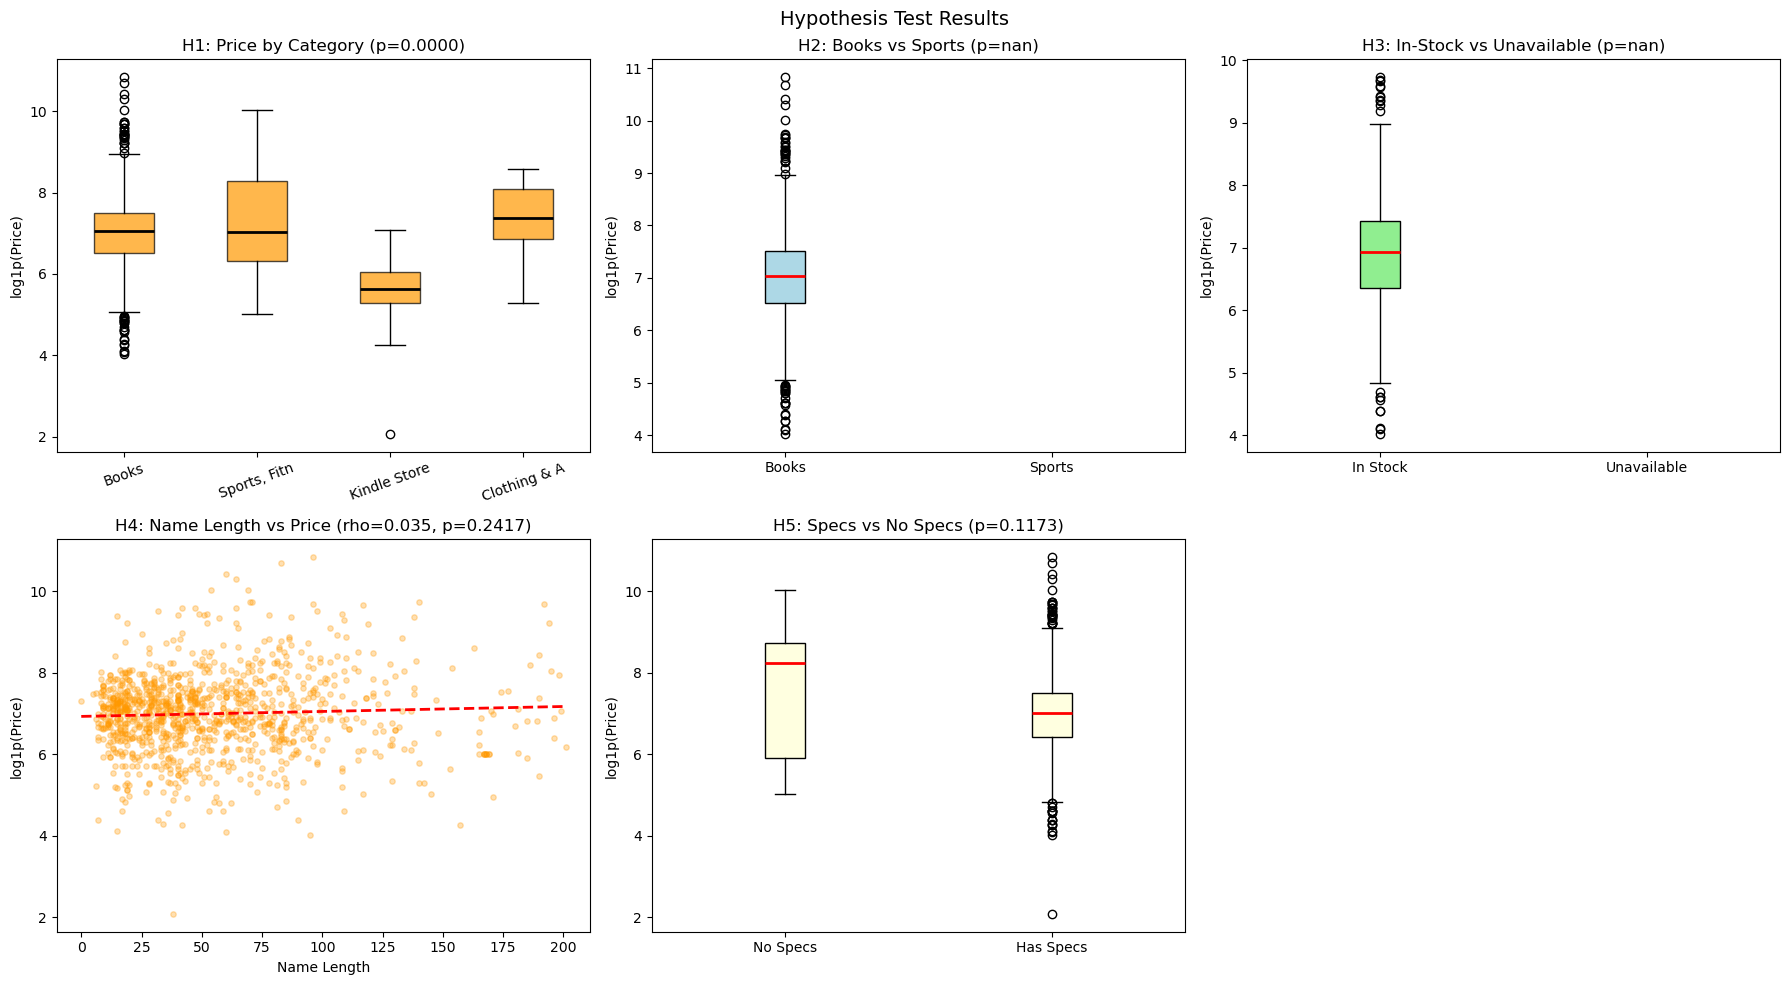

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# =========================
# H1 - Categorías
# =========================
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    tick_labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[0,0].set_title(f'H1: Price by Category (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Price)')
axes[0,0].tick_params(axis='x', rotation=20)

# =========================
# H2 - Books vs Sports
# =========================
axes[0,1].boxplot(
    [
        np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
        np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])
    ],
    tick_labels=['Books','Sports'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)
axes[0,1].set_title(f'H2: Books vs Sports (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Price)')

# =========================
# H3 - Stock
# =========================
axes[0,2].boxplot(
    [
        np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
        np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])
    ],
    tick_labels=['In Stock','Unavailable'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)
axes[0,2].set_title(f'H3: In-Stock vs Unavailable (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Price)')

# =========================
# H4 - Correlación
# =========================
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

m, b = np.polyfit(
    df_priced['name_length'].dropna(),
    df_priced['log_price'].dropna(),
    1
)

x = np.linspace(
    df_priced['name_length'].min(),
    df_priced['name_length'].max(),
    100
)

axes[1,0].plot(x, m*x + b, 'r--', lw=2)

axes[1,0].set_title(f'H4: Name Length vs Price (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Name Length')
axes[1,0].set_ylabel('log1p(Price)')

# =========================
# H5 - Specs
# =========================
axes[1,1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])
    ],
    tick_labels=['No Specs','Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)

axes[1,1].set_title(f'H5: Specs vs No Specs (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Price)')

# =========================
# Empty plot
# =========================
axes[1,2].set_visible(False)

# =========================
# Final layout
# =========================
plt.suptitle('Hypothesis Test Results', fontsize=14)
plt.tight_layout()
plt.show()

## 9.1 Predicción del precio del producto (escala logarítmica)

Predecir el precio de los productos utilizando variables como la categoría, la longitud del nombre,
la disponibilidad y variables indicadoras de características (feature flags).

⚠️ Columnas faltantes detectadas:
['is_kindle', 'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling', 'is_lowstock', 'cat1_enc', 'avail_enc']

✅ Features disponibles: 10 / 18
✅ ML dataset shape : (1093, 12)
✅ Features usados  : 10

Train: 874 | Test: 219


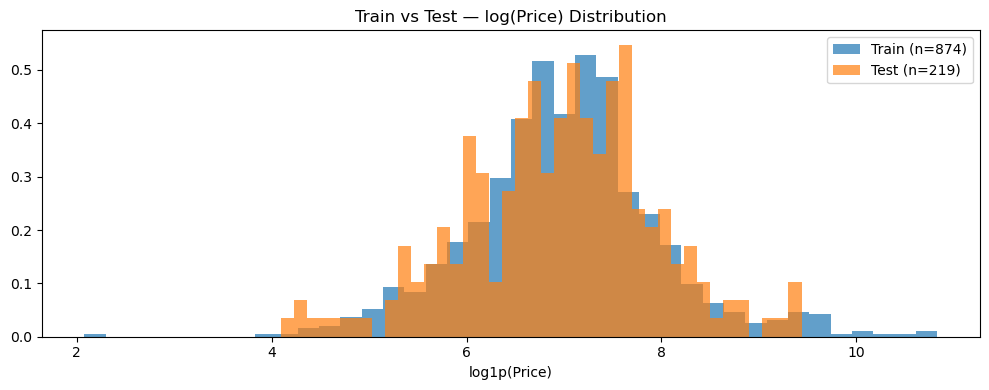

✅ Distribuciones similares — split correcto


In [69]:
# ============================================================
# SECTION 9 — ML Problem Framing (FIXED VERSION)
# ===========================================================

# -----------------------------
# 1. Feature columns (original)
# -----------------------------
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

# -----------------------------
# 2. Safety check: missing cols
# -----------------------------
missing_cols = [col for col in FEATURE_COLS if col not in df_priced.columns]

if len(missing_cols) > 0:
    print("⚠️ Columnas faltantes detectadas:")
    print(missing_cols)

# Solo usar las que sí existen
existing_features = [col for col in FEATURE_COLS if col in df_priced.columns]

print(f"\n✅ Features disponibles: {len(existing_features)} / {len(FEATURE_COLS)}")

# -----------------------------
# 3. Build ML dataset safely
# -----------------------------
df_ml = df_priced[existing_features + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ ML dataset shape : {df_ml.shape}')
print(f'✅ Features usados  : {len(existing_features)}')

# -----------------------------
# 4. Split X / y
# -----------------------------
X = df_ml[existing_features]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# -----------------------------
# 5. Scaling
# -----------------------------
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# -----------------------------
# 6. Visualisation
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    alpha=0.7,
    label=f'Train (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    alpha=0.7,
    label=f'Test (n={len(y_test)})',
    density=True
)

ax.set_title('Train vs Test — log(Price) Distribution')
ax.set_xlabel('log1p(Price)')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Distribuciones similares — split correcto')